In [1]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torchvision.transforms as T
import glob
class CustomDataset(Dataset):
    def __init__(self, dir_path, size=224):
        self.before_paths = sorted(glob.glob(f'{dir_path}/*before*'))
        self.after_paths = sorted(glob.glob(f'{dir_path}/*after*'))
        
        assert len(self.before_paths) == len(self.after_paths), 'file pair error'
        
        self.transform = T.Compose([
            T.Resize((size, size)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]),
        ])
    
    def __len__(self):
        return len(self.before_paths)

    def __getitem__(self, idx):
        before_img = self.transform(Image.open(self.before_paths[idx]).convert("RGB"))
        after_img = self.transform(Image.open(self.after_paths[idx]).convert("RGB"))
        return {"before": before_img, "after": after_img}

In [2]:
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler
from peft import get_peft_model, LoraConfig, TaskType
from transformers import CLIPModel
import torch

# Load base components
# 1. CLIP 모델과 프로세서 로드
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to("cuda")
clip_model.eval()

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to("cuda")
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to("cuda")
noise_scheduler = DDPMScheduler.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="scheduler")

target_modules = [
    name for name, module in unet.named_modules()
    if any(x in name for x in ["to_q", "to_k", "to_v", "to_out.0"]) and isinstance(module, torch.nn.Linear)
]

# Apply LoRA to UNet
lora_config = LoraConfig(
    r=8, lora_alpha=16, target_modules=target_modules,
    bias="none"
)
unet.add_adapter(lora_config)

/home/qkboo/.pyenv/versions/Goodyoung_P312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
from tqdm import tqdm
import time

# 3. 데이터셋과 옵티마이저 준비
dataset = CustomDataset("./dog_before&after")
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)

# 4. 학습 루프
for epoch in tqdm(range(200)):
    for batch in dataloader:
        before = batch["before"].to("cuda")  # [B, 3, H, W]
        after = batch["after"].to("cuda")
        
        with torch.no_grad():
            # before image latent 변환 -> text prompt 형식으로
            before_embed = clip_model.get_image_features(pixel_values=before)  # [B, 768]
            before_latent = before_embed.unsqueeze(1).repeat(1, 77, 1)  # [B, 77, 768]
            
            # after image latent 변환
            after_latent = vae.encode(after).latent_dist.sample() * 0.18215 # scaling_factor: 0.18215
            
        # Diffusion input
        noise = torch.randn_like(after_latent)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (after_latent.size(0),), device=after.device).long()
        noisy_latents = noise_scheduler.add_noise(after_latent, noise, timesteps)

        # UNet prediction
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=before_latent).sample
        loss = F.mse_loss(noise_pred, noise)

        # Optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"[Epoch {epoch+1}] Loss: {loss.item():.4f}")

  0%|          | 1/200 [00:04<14:18,  4.31s/it]

[Epoch 1] Loss: 0.2171


  1%|          | 2/200 [00:07<12:34,  3.81s/it]

[Epoch 2] Loss: 0.1795


  2%|▏         | 3/200 [00:11<11:52,  3.62s/it]

...

[Epoch 198] Loss: 0.1503


100%|█████████▉| 199/200 [11:39<00:03,  3.79s/it]

[Epoch 199] Loss: 0.2882


100%|██████████| 200/200 [11:42<00:00,  3.51s/it]

[Epoch 200] Loss: 0.4081


In [ ]:
# 1. encoder_hidden_state : None으로
# 2. 이미지 100개로
# 3. epoch

### Inference

In [5]:
import torch
from PIL import Image
import torchvision.transforms as T
from transformers import CLIPModel, CLIPImageProcessor

# 🔧 transform 정의 (CLIP용: 224x224 + 정규화)
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

# 1. before 이미지 불러오기 + transform
before = transform(Image.open("../Boss-Before.webp").convert("RGB")).unsqueeze(0).to("cuda") # [1, 3, 224, 224]

# 2. CLIP 모델과 이미지 프로세서 로드
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to("cuda")
clip_model.eval()  # inference mode

# 3. CLIP에 before 이미지 임베딩 전달
with torch.no_grad():
    before_embed = clip_model.get_image_features(pixel_values=before)  # [1, 768]
    encoder_hidden_states = before_embed.unsqueeze(1).repeat(1, 77, 1)  # [1, 77, 768]

# 4. latent 초기화 (pure noise)
latents = torch.randn((1, 4, 64, 64)).to("cuda")

# 5. Reverse diffusion process
for t in tqdm(reversed(range(1000))):
    t_tensor = torch.tensor([t], device=latents.device).long()
    with torch.no_grad():
        noise_pred = unet(latents, t_tensor, encoder_hidden_states=encoder_hidden_states).sample
        latents = noise_scheduler.step(noise_pred, t_tensor, latents).prev_sample

# 6. latent → 이미지 복원
with torch.no_grad():
    image = vae.decode(latents / 0.18215).sample  # [1, 3, 512, 512] 예상

1000it [01:29, 11.18it/s]


### 시각화

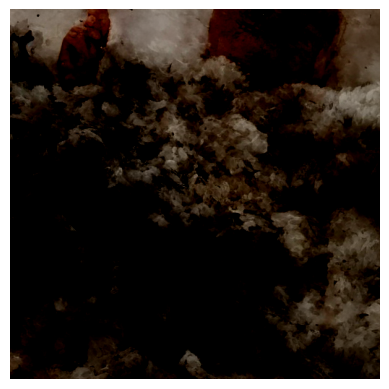

In [6]:
import torchvision.transforms as T
import matplotlib.pyplot as plt

# 💡 1. Clamp to [0, 1]
image = image.clamp(0, 1)

# 💡 2. Get first image (if batch)
img_tensor = image[0].detach().cpu()  # shape: [3, H, W]

# 💡 3. Convert to PIL
to_pil = T.ToPILImage()
pil_image = to_pil(img_tensor)

# 💡 4. Visualize
plt.imshow(pil_image)
plt.axis("off")
plt.show()
